# Simulação de Portfólio de Varejo — Credit Risk+ Dinâmico

Simulação de 24 meses de um portfólio de crédito de varejo com ~1 milhão de clientes, incluindo:
- Migração de rating mês a mês (upgrades e downgrades)
- **Choque macroeconômico no mês 12** que afeta mais os ratings limítrofes (C–F)
- Capital econômico (VaR 99,9%) e EL mensais via Credit Risk+
- Contribuição marginal de risco por segmento de rating
- **RARoC** (Risk-Adjusted Return on Capital) por rating e por mês

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
import warnings, sys
warnings.filterwarnings('ignore')
sys.path.insert(0, '..')

from creditriskplus.simple_model import _sector_distribution

np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

def fmt_bi(x): return f'${x/1e9:.2f}B'
def fmt_mi(x): return f'${x/1e6:.1f}M'
def fmt_pct(x): return f'{x*100:.2f}%'

In [26]:
# ── Parâmetros do portfólio ──────────────────────────────────────────────────
RATINGS      = ['A','B','C','D','E','F','G','H']
N_RATINGS    = 8
N_MONTHS     = 24
N_CLIENTS    = 1_000_000
SHOCK_MONTH  = 12          # primeiro mês afetado (base-0)
SHOCK_DUR    = 4           # duração do choque em meses
RECOVERY     = 0.35
FUNDING_COST = 0.03        # custo de funding anual
OP_COST_YR   = 60          # custo operacional por cliente/ano ($)

# Parâmetros anuais de default por rating
MEAN_PD = np.array([0.0020, 0.0050, 0.0100, 0.0200,
                    0.0500, 0.1000, 0.1500, 0.2500])
STD_PD  = MEAN_PD * 0.50   # CV = 50%

# Mensalização: PD mensal ≈ PD anual / 12
M_PD  = MEAN_PD / 12
M_STD = STD_PD  / 12

# Exposição média por contraparte (menor rating → menor empréstimo)
AVG_EXP = np.array([45_000, 35_000, 28_000, 20_000,
                    15_000, 10_000,  7_000,  5_000])

# Spread anual por rating (acima do custo de funding)
SPREAD  = np.array([0.020, 0.030, 0.045, 0.065,
                    0.090, 0.130, 0.180, 0.250])

# Distribuição inicial de 1M clientes pelos ratings
INIT_DIST = np.array([0.05, 0.10, 0.15, 0.20,
                      0.20, 0.15, 0.10, 0.05])

# Cores por rating
RATING_COLORS = ['#1a9641','#78c679','#d9ef8b','#fee08b',
                 '#fdae61','#f46d43','#d73027','#a50026']

print('Portfólio inicial:')
for r, d, e, p, s in zip(RATINGS, INIT_DIST, AVG_EXP, MEAN_PD*100, SPREAD*100):
    n = int(d * N_CLIENTS)
    print(f'  {r}: {n:>8,} clientes | Exp médio: ${e:>6,} | PD: {p:.2f}% | Spread: {s:.1f}%')
total_exp = (INIT_DIST * N_CLIENTS * AVG_EXP).sum()
print(f'\nExposição total inicial: {fmt_bi(total_exp)}')

Portfólio inicial:
  A:   50,000 clientes | Exp médio: $45,000 | PD: 0.20% | Spread: 2.0%
  B:  100,000 clientes | Exp médio: $35,000 | PD: 0.50% | Spread: 3.0%
  C:  150,000 clientes | Exp médio: $28,000 | PD: 1.00% | Spread: 4.5%
  D:  200,000 clientes | Exp médio: $20,000 | PD: 2.00% | Spread: 6.5%
  E:  200,000 clientes | Exp médio: $15,000 | PD: 5.00% | Spread: 9.0%
  F:  150,000 clientes | Exp médio: $10,000 | PD: 10.00% | Spread: 13.0%
  G:  100,000 clientes | Exp médio: $ 7,000 | PD: 15.00% | Spread: 18.0%
  H:   50,000 clientes | Exp médio: $ 5,000 | PD: 25.00% | Spread: 25.0%

Exposição total inicial: $19.40B


In [27]:
# ── Matrizes de transição mensais ───────────────────────────────────────────
# Linha r → probabilidade de migrar para rating 0..7 (+ default como estado absorvente)
P_BASE = np.array([
#    A       B       C       D       E       F       G       H     default
  [0.921,  0.060,  0.012,  0.004,  0.001,  0.000,  0.000,  0.000,  0.002],  # A
  [0.040,  0.893,  0.050,  0.010,  0.004,  0.001,  0.000,  0.000,  0.002],  # B
  [0.005,  0.045,  0.882,  0.050,  0.010,  0.003,  0.001,  0.000,  0.004],  # C ← borderline
  [0.001,  0.005,  0.050,  0.867,  0.060,  0.008,  0.003,  0.001,  0.005],  # D ← borderline
  [0.000,  0.001,  0.005,  0.055,  0.862,  0.050,  0.010,  0.005,  0.012],  # E ← borderline
  [0.000,  0.000,  0.001,  0.005,  0.045,  0.858,  0.050,  0.015,  0.026],  # F ← borderline
  [0.000,  0.000,  0.000,  0.001,  0.005,  0.040,  0.848,  0.038,  0.068],  # G
  [0.000,  0.000,  0.000,  0.000,  0.001,  0.005,  0.035,  0.820,  0.139],  # H
])
assert np.allclose(P_BASE.sum(axis=1), 1.0), 'Linhas devem somar 1'

# Ratings limítrofes que mais sofrem no choque (índices 2..5 = C,D,E,F)
BORDERLINE = [2, 3, 4, 5]

def get_transition(month):
    """Retorna (P_ratings 8×8, P_default 8,) para o mês dado."""
    P = P_BASE.copy()
    shock_factor = 0.0
    if SHOCK_MONTH <= month < SHOCK_MONTH + SHOCK_DUR:
        # Intensidade cresce no início e decai ao final (triangular)
        rel = month - SHOCK_MONTH
        shock_factor = 1.0 - abs(rel - (SHOCK_DUR-1)/2) / ((SHOCK_DUR+1)/2)
        shock_factor = max(0.3, shock_factor)

    if shock_factor > 0:
        MULT = 1.0 + 2.5 * shock_factor   # até 3.5× nos downgrades/defaults
        for r in BORDERLINE:
            # Aumenta downgrades (colunas > r) e default
            down_cols = list(range(r+1, N_RATINGS))
            extra_down = P[r, down_cols] * (MULT - 1)
            extra_def  = P[r, 8] * (MULT - 1)
            reduction  = extra_down.sum() + extra_def
            up_stay    = list(range(0, r+1))
            total_us   = P[r, up_stay].sum()
            if total_us > 0:
                P[r, up_stay]   -= reduction * P[r, up_stay] / total_us
                P[r, down_cols] += extra_down
                P[r, 8]         += extra_def
        P = np.maximum(P, 0)
        P = P / P.sum(axis=1, keepdims=True)

    return P[:, :8], P[:, 8]

# Inspeciona o mês 12 (choque)
P_shock, d_shock = get_transition(12)
P_norm,  d_norm  = get_transition(0)
print('Probabilidade de default mensal (normal vs choque):')
for r, dn, ds in zip(RATINGS, d_norm, d_shock):
    mult = ds/dn if dn > 0 else 1
    print(f'  {r}: normal={dn:.4%}  choque={ds:.4%}  (×{mult:.1f})')

Probabilidade de default mensal (normal vs choque):
  A: normal=0.2000%  choque=0.2000%  (×1.0)
  B: normal=0.2000%  choque=0.2000%  (×1.0)
  C: normal=0.4000%  choque=0.8000%  (×2.0)
  D: normal=0.5000%  choque=1.0000%  (×2.0)
  E: normal=1.2000%  choque=2.4000%  (×2.0)
  F: normal=2.6000%  choque=5.2000%  (×2.0)
  G: normal=6.8000%  choque=6.8000%  (×1.0)
  H: normal=13.9000%  choque=13.9000%  (×1.0)


In [28]:
# ── Simulação de 24 meses ───────────────────────────────────────────────────
# Portfolio state: counts[t, r] = nº clientes no rating r no mês t
counts = np.zeros((N_MONTHS+1, N_RATINGS), dtype=np.int64)
counts[0] = np.round(INIT_DIST * N_CLIENTS).astype(int)

# Reposição: clientes novos chegam mensalmente para repor defaults
# Entrando nos ratings A–D (clientes novos tendem a ser melhores)
REPLENISH_DIST = np.array([0.10, 0.20, 0.25, 0.25, 0.15, 0.05, 0.00, 0.00])

defaults_per_month = np.zeros((N_MONTHS, N_RATINGS), dtype=np.int64)
shock_factors      = np.zeros(N_MONTHS)

for t in range(N_MONTHS):
    P_r, P_d = get_transition(t)

    # Guarda intensidade do choque para plots
    if SHOCK_MONTH <= t < SHOCK_MONTH + SHOCK_DUR:
        rel = t - SHOCK_MONTH
        shock_factors[t] = max(0.3, 1.0 - abs(rel - (SHOCK_DUR-1)/2) / ((SHOCK_DUR+1)/2))

    new_counts = np.zeros(N_RATINGS, dtype=np.int64)
    for r in range(N_RATINGS):
        n = int(counts[t, r])
        if n == 0:
            continue
        # Sorteia destino de cada cliente: 8 ratings + default
        probs = np.append(P_r[r], P_d[r])
        probs = probs / probs.sum()   # garante soma = 1
        drawn = np.random.multinomial(n, probs)
        new_counts          += drawn[:N_RATINGS]
        defaults_per_month[t, r] = drawn[8]

    # Repõe clientes defaults com novos clientes
    total_def = defaults_per_month[t].sum()
    replenish = np.round(REPLENISH_DIST * total_def).astype(int)
    replenish[0] += total_def - replenish.sum()  # ajuste de arredondamento
    new_counts += replenish

    counts[t+1] = new_counts

print('Simulação concluída. Resumo por período:')
print(f'{"Mês":>4} | {"Total":>9} | {"A–D":>8} | {"E–H":>8} | {"Defaults":>9} | {"Choque":>7}')
print('-' * 60)
for t in [0,6,11,12,13,15,18,23]:
    tot = counts[t].sum()
    good = counts[t,:4].sum()
    risky= counts[t,4:].sum()
    defs = defaults_per_month[t-1].sum() if t > 0 else 0
    sf   = shock_factors[t-1] if t > 0 else 0
    print(f'{t:>4} | {tot:>9,} | {good:>8,} | {risky:>8,} | {defs:>9,} | {sf:>7.2f}')

Simulação concluída. Resumo por período:
 Mês |     Total |      A–D |      E–H |  Defaults |  Choque
------------------------------------------------------------
   0 | 1,000,000 |  500,000 |  500,000 |         0 |    0.00
   6 | 1,000,000 |  560,439 |  439,561 |    19,239 |    0.00
  11 | 1,000,000 |  595,223 |  404,777 |    17,765 |    0.00
  12 | 1,000,000 |  601,125 |  398,875 |    17,299 |    0.00
  13 | 1,000,000 |  593,095 |  406,905 |    24,074 |    0.40
  15 | 1,000,000 |  557,203 |  442,797 |    32,677 |    0.80
  18 | 1,000,000 |  576,941 |  423,059 |    20,437 |    0.00
  23 | 1,000,000 |  616,518 |  383,482 |    17,684 |    0.00


In [29]:
# ── Credit Risk+ mensal: VaR, EL e Capital ──────────────────────────────────
# Representamos o portfólio como 8 "super-contrapartes" (uma por rating).
# Todos ν_r = 1 porque net_e_r << L=$1M  →  recursão NB simples: O(MAX_N).
# A[0] = (1-p)^α;  A[n] = p(α-1+n)/n · A[n-1]

NET_EXP = AVG_EXP * (1.0 - RECOVERY)
L       = 1_000_000.0   # $1 M por unidade de perda do portfólio
MAX_N   = 2_000         # cobre $2 B — suficiente para VaR 99,9%

monthly_EL   = np.zeros(N_MONTHS)
monthly_VaR  = np.zeros(N_MONTHS)   # VaR 99,9%
monthly_VaR2 = np.zeros(N_MONTHS)   # VaR 99,0%
monthly_EC   = np.zeros(N_MONTHS)
monthly_RC   = np.zeros((N_MONTHS, N_RATINGS))

for t in range(N_MONTHS):
    cnt = counts[t].astype(float)

    el_by_rating = cnt * M_PD * NET_EXP
    el_total     = el_by_rating.sum()
    monthly_EL[t] = el_total

    # ε_r = n_r × p_r × net_e_r / L  (todos ν=1, net_e_r << L)
    epsilons = cnt * M_PD  * NET_EXP / L
    sigmas   = cnt * M_STD * NET_EXP / L
    mu_k    = epsilons.sum()
    sigma_k = sigmas.sum()

    A = np.zeros(MAX_N + 1)
    if mu_k <= 0:
        A[0] = 1.0
    elif sigma_k > 0:
        alpha_k = mu_k ** 2 / sigma_k ** 2
        beta_k  = sigma_k ** 2 / mu_k
        p_k     = beta_k / (1.0 + beta_k)
        A[0] = (1.0 - p_k) ** alpha_k
        for n in range(1, MAX_N + 1):
            A[n] = p_k * (alpha_k - 1.0 + n) / n * A[n - 1]
        s = A.sum();  A = A / s if s > 0 else A
    else:
        A[0] = np.exp(-mu_k) if mu_k < 700 else 0.0
        for n in range(1, MAX_N + 1):
            A[n] = mu_k / n * A[n - 1]
        s = A.sum();  A = A / s if s > 0 else A

    cdf = np.cumsum(A)
    monthly_VaR[t]  = min(np.searchsorted(cdf, 0.999), MAX_N) * L
    monthly_VaR2[t] = min(np.searchsorted(cdf, 0.990), MAX_N) * L
    monthly_EC[t]   = max(monthly_VaR[t] - el_total, 0.0)

    if mu_k > 0 and monthly_EC[t] > 0:
        monthly_RC[t] = el_by_rating + monthly_EC[t] * (epsilons / mu_k)
    else:
        monthly_RC[t] = el_by_rating

print(f'Unit size L = ${L:,.0f}  |  MAX_N = {MAX_N:,}  (cobre ${MAX_N*L/1e9:.1f}B)')
print()
print(f'{"Mês":>4} | {"EL":>12} | {"VaR(99%)":>12} | {"VaR(99,9%)":>12} | {"Capital":>12}')
print('-' * 62)
for t in [0, 6, 11, 12, 13, 15, 18, 23]:
    print(f'{t:>4} | {fmt_mi(monthly_EL[t]):>12} | {fmt_mi(monthly_VaR2[t]):>12} | {fmt_mi(monthly_VaR[t]):>12} | {fmt_mi(monthly_EC[t]):>12}')

Unit size L = $1,000,000  |  MAX_N = 2,000  (cobre $2.0B)

 Mês |           EL |     VaR(99%) |   VaR(99,9%) |      Capital
--------------------------------------------------------------
   0 |       $33.1M |       $86.0M |      $113.0M |       $79.9M
   6 |       $30.5M |       $79.0M |      $104.0M |       $73.5M
  11 |       $28.9M |       $76.0M |       $99.0M |       $70.1M
  12 |       $28.6M |       $75.0M |       $98.0M |       $69.4M
  13 |       $28.9M |       $76.0M |       $99.0M |       $70.1M
  15 |       $30.3M |       $79.0M |      $103.0M |       $72.7M
  18 |       $29.5M |       $77.0M |      $101.0M |       $71.5M
  23 |       $27.9M |       $73.0M |       $95.0M |       $67.1M


In [30]:
# ── RARoC mensal por rating ──────────────────────────────────────────────────
# RARoC_r = (Receita_r - EL_r - Custo_funding_r - Custo_op_r) / RC_r
#
# Receita mensal = spread × exposição / 12
# EL mensal = PD_mensal × exposição_líquida
# Custo funding = funding_cost × exposição / 12
# Custo op = OP_COST_YR × n_r / 12

raroc_matrix  = np.full((N_MONTHS, N_RATINGS), np.nan)  # RARoC por rating/mês
raroc_portf   = np.full(N_MONTHS, np.nan)                # RARoC portfólio

revenue_total  = np.zeros(N_MONTHS)
cost_total     = np.zeros(N_MONTHS)
net_income_tot = np.zeros(N_MONTHS)

for t in range(N_MONTHS):
    cnt = counts[t].astype(float)

    receita     = cnt * AVG_EXP * SPREAD / 12
    el_r        = cnt * M_PD * NET_EXP
    custo_fund  = cnt * AVG_EXP * FUNDING_COST / 12
    custo_op    = cnt * OP_COST_YR / 12

    net_income  = receita - el_r - custo_fund - custo_op

    revenue_total[t]  = receita.sum()
    cost_total[t]     = (el_r + custo_fund + custo_op).sum()
    net_income_tot[t] = net_income.sum()

    ec_total = monthly_EC[t]

    for r in range(N_RATINGS):
        rc_r = monthly_RC[t, r]
        if rc_r > 1e3 and cnt[r] > 0:
            raroc_matrix[t, r] = net_income[r] / rc_r   # mensal

    if ec_total > 1e3:
        raroc_portf[t] = net_income.sum() / ec_total

# Anualiza RARoC
raroc_matrix_ann  = raroc_matrix  * 12
raroc_portf_ann   = raroc_portf   * 12

print('RARoC anualizado por rating (seleção de meses):')
print(f'{"":>4}', end='')
for r in RATINGS: print(f'  {r:>8}', end='')
print(f'  {"Total":>8}')
for t in [0, 6, 11, 12, 13, 15, 18, 23]:
    print(f'{t:>4}', end='')
    for r in range(N_RATINGS):
        v = raroc_matrix_ann[t, r]
        print(f'  {v*100:>7.1f}%' if not np.isnan(v) else f'  {"—":>8}', end='')
    print(f'  {raroc_portf_ann[t]*100:>7.1f}%')

RARoC anualizado por rating (seleção de meses):
             A         B         C         D         E         F         G         H     Total
   0  -3418.3%   -537.3%    344.0%    514.1%    254.3%    156.9%    158.5%     98.5%    266.7%
   6  -3417.0%   -537.1%    343.9%    513.9%    254.2%    156.9%    158.4%     98.5%    249.7%
  11  -3405.3%   -535.2%    342.7%    512.1%    253.4%    156.3%    157.9%     98.1%    234.0%
  12  -3408.8%   -535.8%    343.1%    512.7%    253.6%    156.5%    158.0%     98.2%    231.8%
  13  -3408.2%   -535.7%    343.0%    512.6%    253.6%    156.5%    158.0%     98.2%    225.1%
  15  -3435.0%   -539.9%    345.7%    516.6%    255.6%    157.7%    159.3%     99.0%    208.2%
  18  -3407.7%   -535.6%    343.0%    512.5%    253.6%    156.5%    158.0%     98.2%    200.1%
  23  -3419.3%   -537.4%    344.1%    514.2%    254.4%    157.0%    158.5%     98.5%    197.0%


## Análise Gráfica

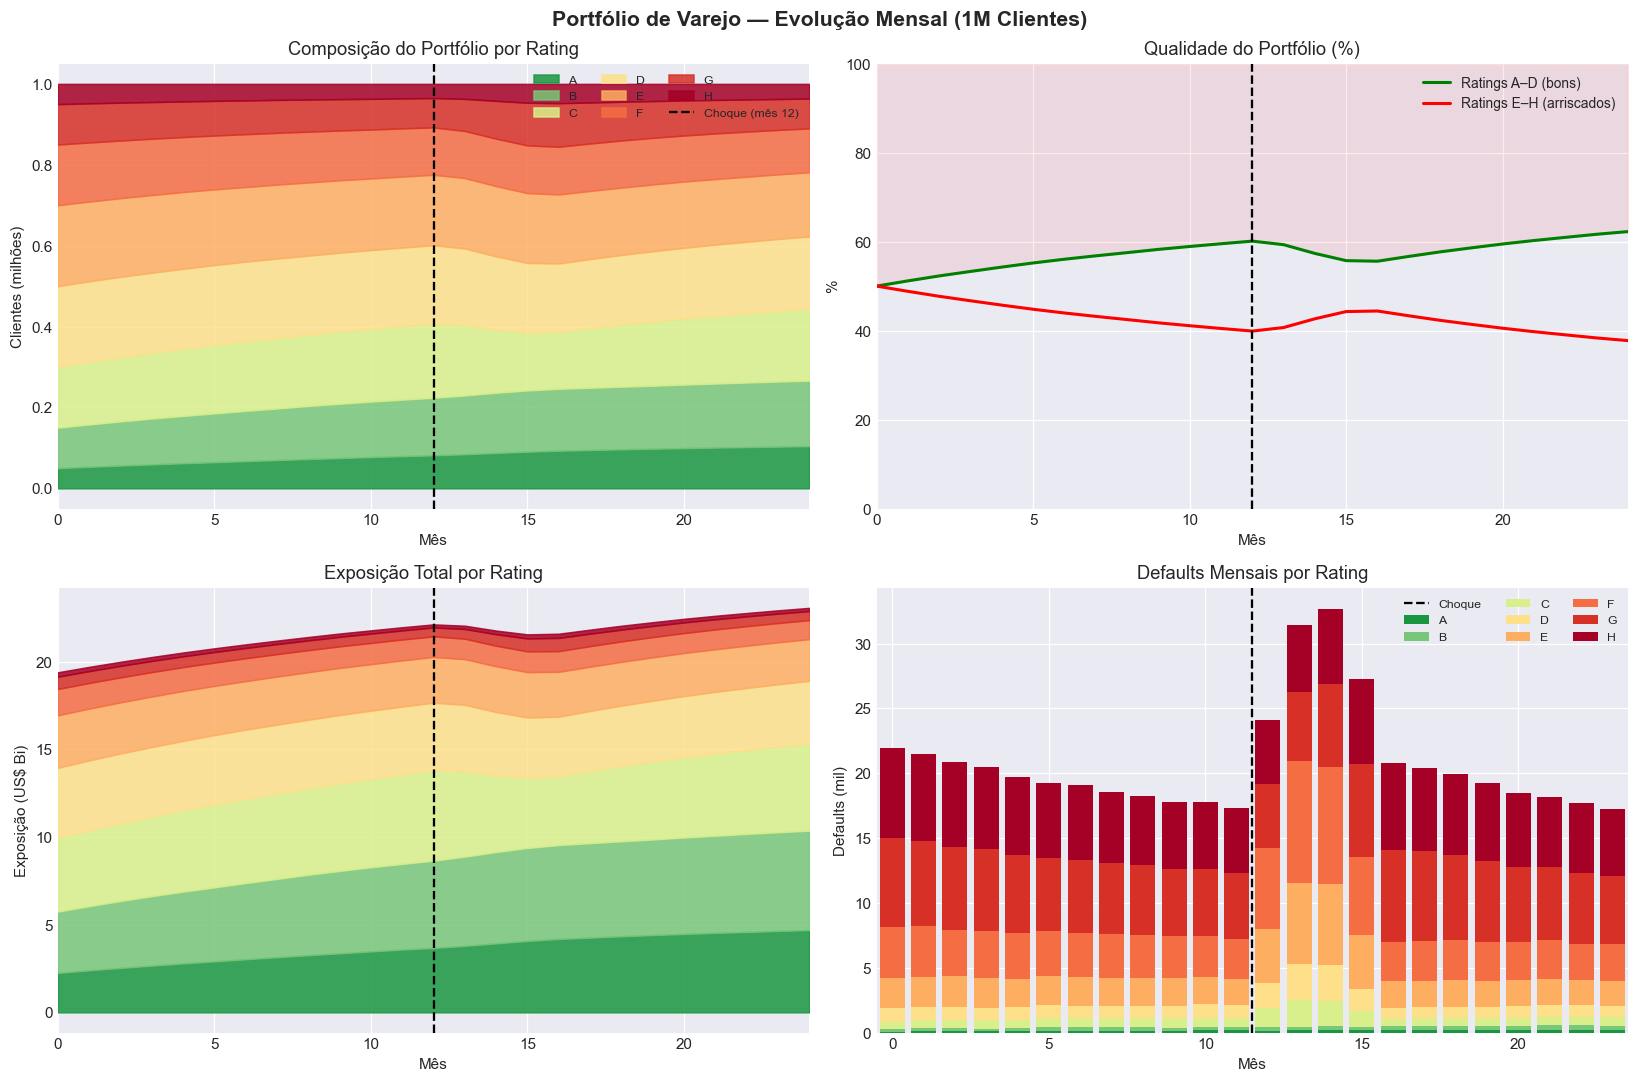

In [31]:
# ── Plot 1: Composição do portfólio ao longo do tempo ───────────────────────
months = np.arange(N_MONTHS + 1)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1a. Stacked area — nº de clientes
ax = axes[0, 0]
bottom = np.zeros(N_MONTHS + 1)
for r in range(N_RATINGS):
    ax.fill_between(months, bottom, bottom + counts[:, r]/1e6,
                    color=RATING_COLORS[r], alpha=0.85, label=RATINGS[r])
    bottom += counts[:, r]/1e6
ax.axvline(SHOCK_MONTH, color='black', linestyle='--', lw=1.5, label='Choque (mês 12)')
ax.set_xlabel('Mês'); ax.set_ylabel('Clientes (milhões)')
ax.set_title('Composição do Portfólio por Rating')
ax.legend(loc='upper right', fontsize=8, ncol=3)
ax.set_xlim([0, N_MONTHS])

# 1b. % de clientes por qualidade
ax = axes[0, 1]
good_pct  = counts[:, :4].sum(axis=1) / counts.sum(axis=1) * 100
risky_pct = counts[:, 4:].sum(axis=1) / counts.sum(axis=1) * 100
ax.plot(months, good_pct,  color='green', lw=2, label='Ratings A–D (bons)')
ax.plot(months, risky_pct, color='red',   lw=2, label='Ratings E–H (arriscados)')
ax.axvline(SHOCK_MONTH, color='black', linestyle='--', lw=1.5)
ax.fill_between(months, good_pct, 100, alpha=0.08, color='red')
ax.set_xlabel('Mês'); ax.set_ylabel('%')
ax.set_title('Qualidade do Portfólio (%)')
ax.legend(fontsize=9); ax.set_xlim([0, N_MONTHS]); ax.set_ylim([0, 100])

# 1c. Exposição total por rating (mês a mês)
ax = axes[1, 0]
exp_matrix = counts * AVG_EXP  # total exposure per rating per month
bottom = np.zeros(N_MONTHS + 1)
for r in range(N_RATINGS):
    ax.fill_between(months, bottom/1e9, (bottom + exp_matrix[:, r])/1e9,
                    color=RATING_COLORS[r], alpha=0.85, label=RATINGS[r])
    bottom += exp_matrix[:, r]
ax.axvline(SHOCK_MONTH, color='black', linestyle='--', lw=1.5)
ax.set_xlabel('Mês'); ax.set_ylabel('Exposição (US$ Bi)')
ax.set_title('Exposição Total por Rating')
ax.set_xlim([0, N_MONTHS])

# 1d. Defaults mensais por rating (stacked)
ax = axes[1, 1]
bottom = np.zeros(N_MONTHS)
for r in range(N_RATINGS):
    ax.bar(range(N_MONTHS), defaults_per_month[:, r]/1000,
           bottom=bottom/1000, color=RATING_COLORS[r], label=RATINGS[r])
    bottom += defaults_per_month[:, r].astype(float)
ax.axvline(SHOCK_MONTH - 0.5, color='black', linestyle='--', lw=1.5, label='Choque')
ax.set_xlabel('Mês'); ax.set_ylabel('Defaults (mil)')
ax.set_title('Defaults Mensais por Rating')
ax.legend(fontsize=8, ncol=3); ax.set_xlim([-0.5, N_MONTHS-0.5])

plt.suptitle('Portfólio de Varejo — Evolução Mensal (1M Clientes)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../references/plot_portfolio_evolution.png', dpi=120, bbox_inches='tight')
plt.show()

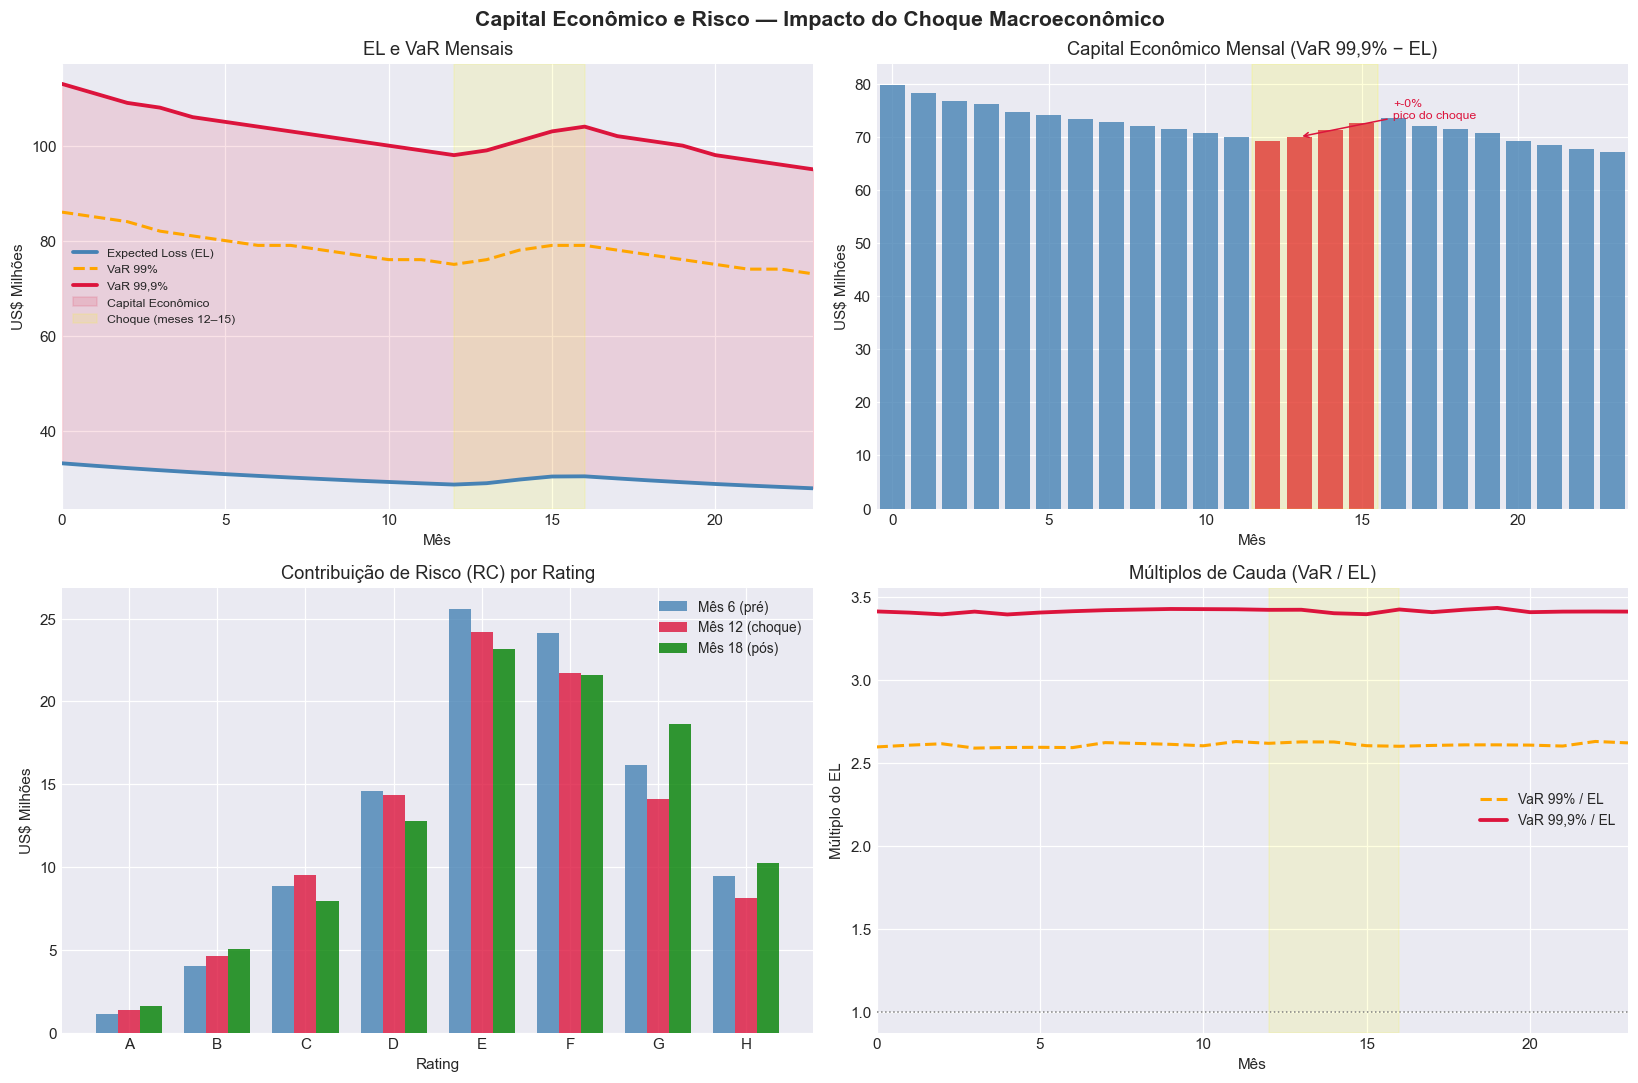

In [32]:
# ── Plot 2: EL, VaR e Capital Econômico ─────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
m = np.arange(N_MONTHS)

# 2a. EL e VaR ao longo do tempo
ax = axes[0, 0]
ax.plot(m, monthly_EL/1e6,   color='steelblue', lw=2.5, label='Expected Loss (EL)')
ax.plot(m, monthly_VaR2/1e6, color='orange',    lw=2,   linestyle='--', label='VaR 99%')
ax.plot(m, monthly_VaR/1e6,  color='crimson',   lw=2.5, label='VaR 99,9%')
ax.fill_between(m, monthly_EL/1e6, monthly_VaR/1e6, alpha=0.12, color='crimson', label='Capital Econômico')
ax.axvspan(SHOCK_MONTH, SHOCK_MONTH+SHOCK_DUR, alpha=0.12, color='yellow', label=f'Choque (meses {SHOCK_MONTH}–{SHOCK_MONTH+SHOCK_DUR-1})')
ax.set_xlabel('Mês'); ax.set_ylabel('US$ Milhões')
ax.set_title('EL e VaR Mensais')
ax.legend(fontsize=8); ax.set_xlim([0, N_MONTHS-1])

# 2b. Capital Econômico (EC)
ax = axes[0, 1]
ax.bar(m, monthly_EC/1e6, color=['crimson' if SHOCK_MONTH<=t<SHOCK_MONTH+SHOCK_DUR else 'steelblue' for t in m], alpha=0.8)
ax.axvspan(SHOCK_MONTH-0.5, SHOCK_MONTH+SHOCK_DUR-0.5, alpha=0.15, color='yellow')
ax.set_xlabel('Mês'); ax.set_ylabel('US$ Milhões')
ax.set_title('Capital Econômico Mensal (VaR 99,9% − EL)')
ax.set_xlim([-0.5, N_MONTHS-0.5])
pct_inc = (monthly_EC[13] - monthly_EC[11]) / monthly_EC[11] * 100
ax.annotate(f'+{pct_inc:.0f}%\npico do choque', xy=(13, monthly_EC[13]/1e6),
            xytext=(16, monthly_EC[13]/1e6*1.05), fontsize=8, color='crimson',
            arrowprops=dict(arrowstyle='->', color='crimson'))

# 2c. Decomposição RC por rating (mês 6 vs 12 vs 18)
ax = axes[1, 0]
x = np.arange(N_RATINGS)
w = 0.25
for i, (t, lbl, col) in enumerate([(6,'Mês 6 (pré)','steelblue'),(12,'Mês 12 (choque)','crimson'),(18,'Mês 18 (pós)','green')]):
    ax.bar(x + i*w, monthly_RC[t]/1e6, w, label=lbl, color=col, alpha=0.8)
ax.set_xticks(x + w); ax.set_xticklabels(RATINGS)
ax.set_xlabel('Rating'); ax.set_ylabel('US$ Milhões')
ax.set_title('Contribuição de Risco (RC) por Rating')
ax.legend(fontsize=9)

# 2d. EL / VaR ratio (caudas como múltiplo do EL)
ax = axes[1, 1]
ratio_99  = monthly_VaR2 / np.maximum(monthly_EL, 1)
ratio_999 = monthly_VaR  / np.maximum(monthly_EL, 1)
ax.plot(m, ratio_99,  color='orange',  lw=2, linestyle='--', label='VaR 99% / EL')
ax.plot(m, ratio_999, color='crimson', lw=2.5, label='VaR 99,9% / EL')
ax.axhline(1.0, color='gray', linestyle=':', lw=1)
ax.axvspan(SHOCK_MONTH, SHOCK_MONTH+SHOCK_DUR, alpha=0.12, color='yellow')
ax.set_xlabel('Mês'); ax.set_ylabel('Múltiplo do EL')
ax.set_title('Múltiplos de Cauda (VaR / EL)')
ax.legend(fontsize=9); ax.set_xlim([0, N_MONTHS-1])

plt.suptitle('Capital Econômico e Risco — Impacto do Choque Macroeconômico', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

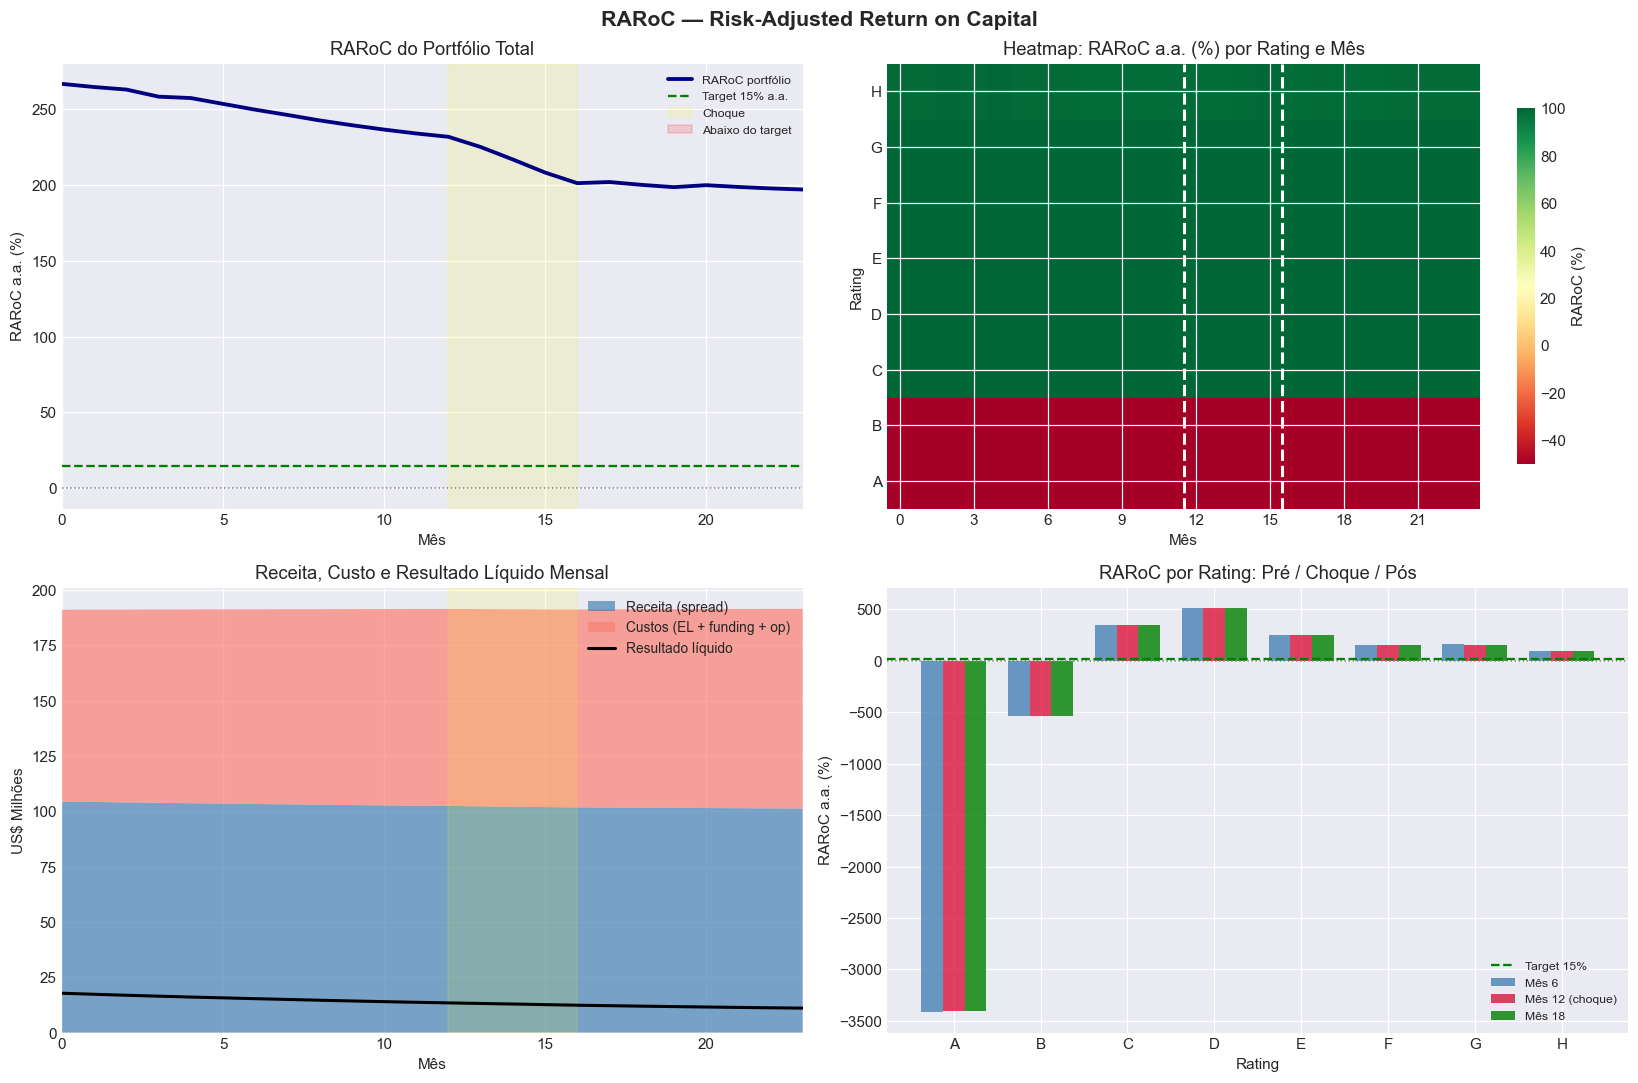

In [33]:
# ── Plot 3: RARoC ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 3a. RARoC do portfólio total ao longo do tempo
ax = axes[0, 0]
valid = ~np.isnan(raroc_portf_ann)
ax.plot(m[valid], raroc_portf_ann[valid]*100, color='navy', lw=2.5, label='RARoC portfólio')
ax.axhline(0, color='gray', linestyle=':', lw=1)
ax.axhline(15, color='green', linestyle='--', lw=1.5, label='Target 15% a.a.')
ax.axvspan(SHOCK_MONTH, SHOCK_MONTH+SHOCK_DUR, alpha=0.12, color='yellow', label='Choque')
ax.fill_between(m[valid], raroc_portf_ann[valid]*100, 15, 
                where=raroc_portf_ann[valid]*100 < 15, alpha=0.15, color='red', label='Abaixo do target')
ax.set_xlabel('Mês'); ax.set_ylabel('RARoC a.a. (%)')
ax.set_title('RARoC do Portfólio Total')
ax.legend(fontsize=8); ax.set_xlim([0, N_MONTHS-1])

# 3b. RARoC por rating — heatmap
ax = axes[0, 1]
raroc_plot = raroc_matrix_ann * 100
im = ax.imshow(raroc_plot.T, aspect='auto', cmap='RdYlGn',
               vmin=-50, vmax=100, origin='lower')
ax.set_xticks(range(0, N_MONTHS, 3))
ax.set_xticklabels(range(0, N_MONTHS, 3))
ax.set_yticks(range(N_RATINGS)); ax.set_yticklabels(RATINGS)
ax.set_xlabel('Mês'); ax.set_ylabel('Rating')
ax.set_title('Heatmap: RARoC a.a. (%) por Rating e Mês')
plt.colorbar(im, ax=ax, label='RARoC (%)', shrink=0.8)
# Marca região de choque
ax.axvline(SHOCK_MONTH - 0.5, color='white', lw=2, linestyle='--')
ax.axvline(SHOCK_MONTH + SHOCK_DUR - 0.5, color='white', lw=2, linestyle='--')

# 3c. Receita, Custo e Resultado líquido
ax = axes[1, 0]
ax.stackplot(m, revenue_total/1e6, cost_total/1e6, 
             labels=['Receita (spread)', 'Custos (EL + funding + op)'],
             colors=['steelblue', 'salmon'], alpha=0.7)
ax.plot(m, net_income_tot/1e6, color='black', lw=2, label='Resultado líquido')
ax.axvspan(SHOCK_MONTH, SHOCK_MONTH+SHOCK_DUR, alpha=0.12, color='yellow')
ax.set_xlabel('Mês'); ax.set_ylabel('US$ Milhões')
ax.set_title('Receita, Custo e Resultado Líquido Mensal')
ax.legend(fontsize=9); ax.set_xlim([0, N_MONTHS-1])

# 3d. RARoC por rating no mês 6, 12, 18 (barras)
ax = axes[1, 1]
x = np.arange(N_RATINGS); w = 0.25
for i, (t, lbl, col) in enumerate([(6,'Mês 6','steelblue'),(12,'Mês 12 (choque)','crimson'),(18,'Mês 18','green')]):
    vals = raroc_matrix_ann[t] * 100
    ax.bar(x + i*w, vals, w, label=lbl, color=col, alpha=0.8)
ax.axhline(0, color='gray', lw=1, linestyle=':')
ax.axhline(15, color='green', lw=1.5, linestyle='--', label='Target 15%')
ax.set_xticks(x + w); ax.set_xticklabels(RATINGS)
ax.set_xlabel('Rating'); ax.set_ylabel('RARoC a.a. (%)')
ax.set_title('RARoC por Rating: Pré / Choque / Pós')
ax.legend(fontsize=8)

plt.suptitle('RARoC — Risk-Adjusted Return on Capital', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

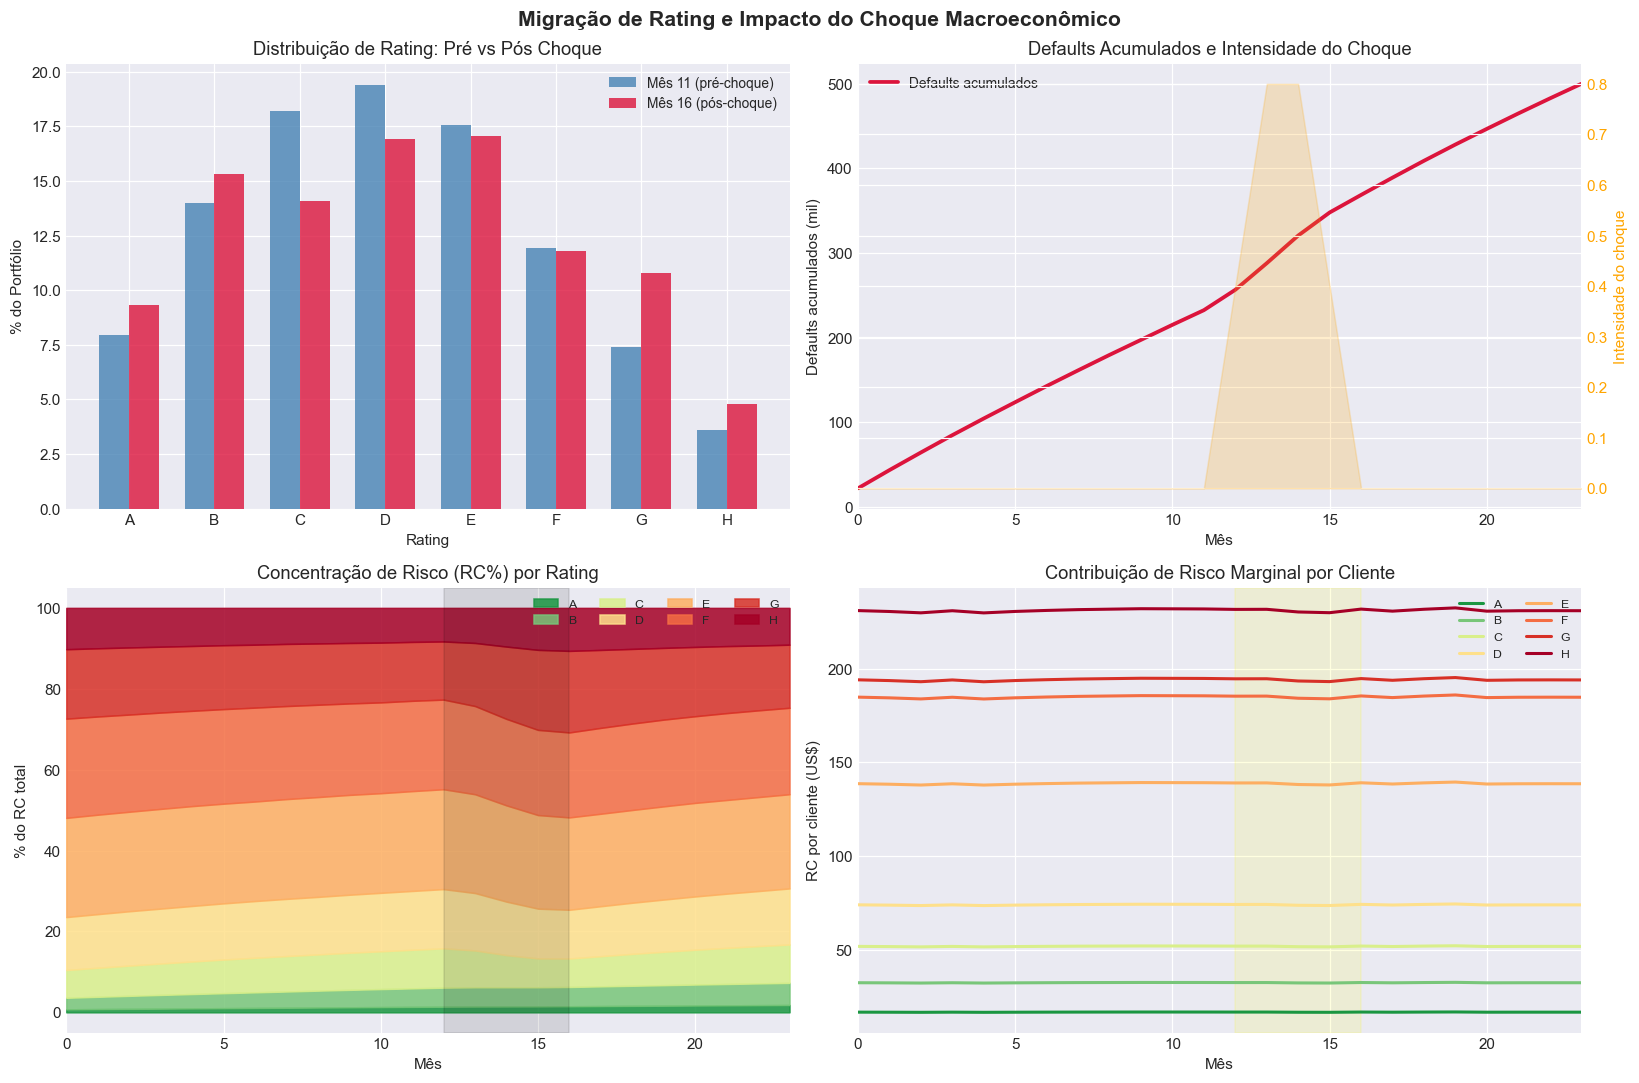

In [34]:
# ── Plot 4: Migração de Rating e Impacto do Choque ───────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 4a. Migração de rating (% de cada rating inicial que migrou)
ax = axes[0, 0]
# Compara distribuição mês 11 (pré-choque) vs 16 (pós-choque)
pre  = counts[11] / counts[11].sum() * 100
pos  = counts[16] / counts[16].sum() * 100
x = np.arange(N_RATINGS); w = 0.35
ax.bar(x - w/2, pre, w, color='steelblue', alpha=0.8, label='Mês 11 (pré-choque)')
ax.bar(x + w/2, pos, w, color='crimson',   alpha=0.8, label='Mês 16 (pós-choque)')
ax.set_xticks(x); ax.set_xticklabels(RATINGS)
ax.set_xlabel('Rating'); ax.set_ylabel('% do Portfólio')
ax.set_title('Distribuição de Rating: Pré vs Pós Choque')
ax.legend(fontsize=9)

# 4b. Migração acumulada para ratings piores (degradação do portfólio)
ax = axes[0, 1]
cum_defaults = defaults_per_month.cumsum(axis=0).sum(axis=1)
ax.plot(m, cum_defaults/1000, color='crimson', lw=2.5, label='Defaults acumulados')
ax2 = ax.twinx()
ax2.fill_between(m, shock_factors, alpha=0.2, color='orange', label='Intensidade do choque')
ax2.set_ylabel('Intensidade do choque', color='orange')
ax2.tick_params(axis='y', colors='orange')
ax.set_xlabel('Mês'); ax.set_ylabel('Defaults acumulados (mil)')
ax.set_title('Defaults Acumulados e Intensidade do Choque')
ax.legend(loc='upper left', fontsize=9)
ax.set_xlim([0, N_MONTHS-1])

# 4c. Concentração de risco por rating (RC% do total)
ax = axes[1, 0]
rc_pct = monthly_RC / monthly_RC.sum(axis=1, keepdims=True) * 100
bottom = np.zeros(N_MONTHS)
for r in range(N_RATINGS):
    ax.fill_between(m, bottom, bottom + rc_pct[:, r],
                    color=RATING_COLORS[r], alpha=0.85, label=RATINGS[r])
    bottom += rc_pct[:, r]
ax.axvspan(SHOCK_MONTH, SHOCK_MONTH+SHOCK_DUR, alpha=0.1, color='black')
ax.set_xlabel('Mês'); ax.set_ylabel('% do RC total')
ax.set_title('Concentração de Risco (RC%) por Rating')
ax.legend(fontsize=8, ncol=4, loc='upper right'); ax.set_xlim([0, N_MONTHS-1])

# 4d. RC por cliente (marginal contribution individual) por rating
ax = axes[1, 1]
rc_per_client = np.zeros((N_MONTHS, N_RATINGS))
for r in range(N_RATINGS):
    mask = counts[:N_MONTHS, r] > 0
    rc_per_client[mask, r] = monthly_RC[mask, r] / counts[:N_MONTHS, r][mask]

for r in range(N_RATINGS):
    ax.plot(m, rc_per_client[:, r], color=RATING_COLORS[r], lw=2, label=RATINGS[r])
ax.axvspan(SHOCK_MONTH, SHOCK_MONTH+SHOCK_DUR, alpha=0.12, color='yellow')
ax.set_xlabel('Mês'); ax.set_ylabel('RC por cliente (US$)')
ax.set_title('Contribuição de Risco Marginal por Cliente')
ax.legend(fontsize=8, ncol=2); ax.set_xlim([0, N_MONTHS-1])

plt.suptitle('Migração de Rating e Impacto do Choque Macroeconômico', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

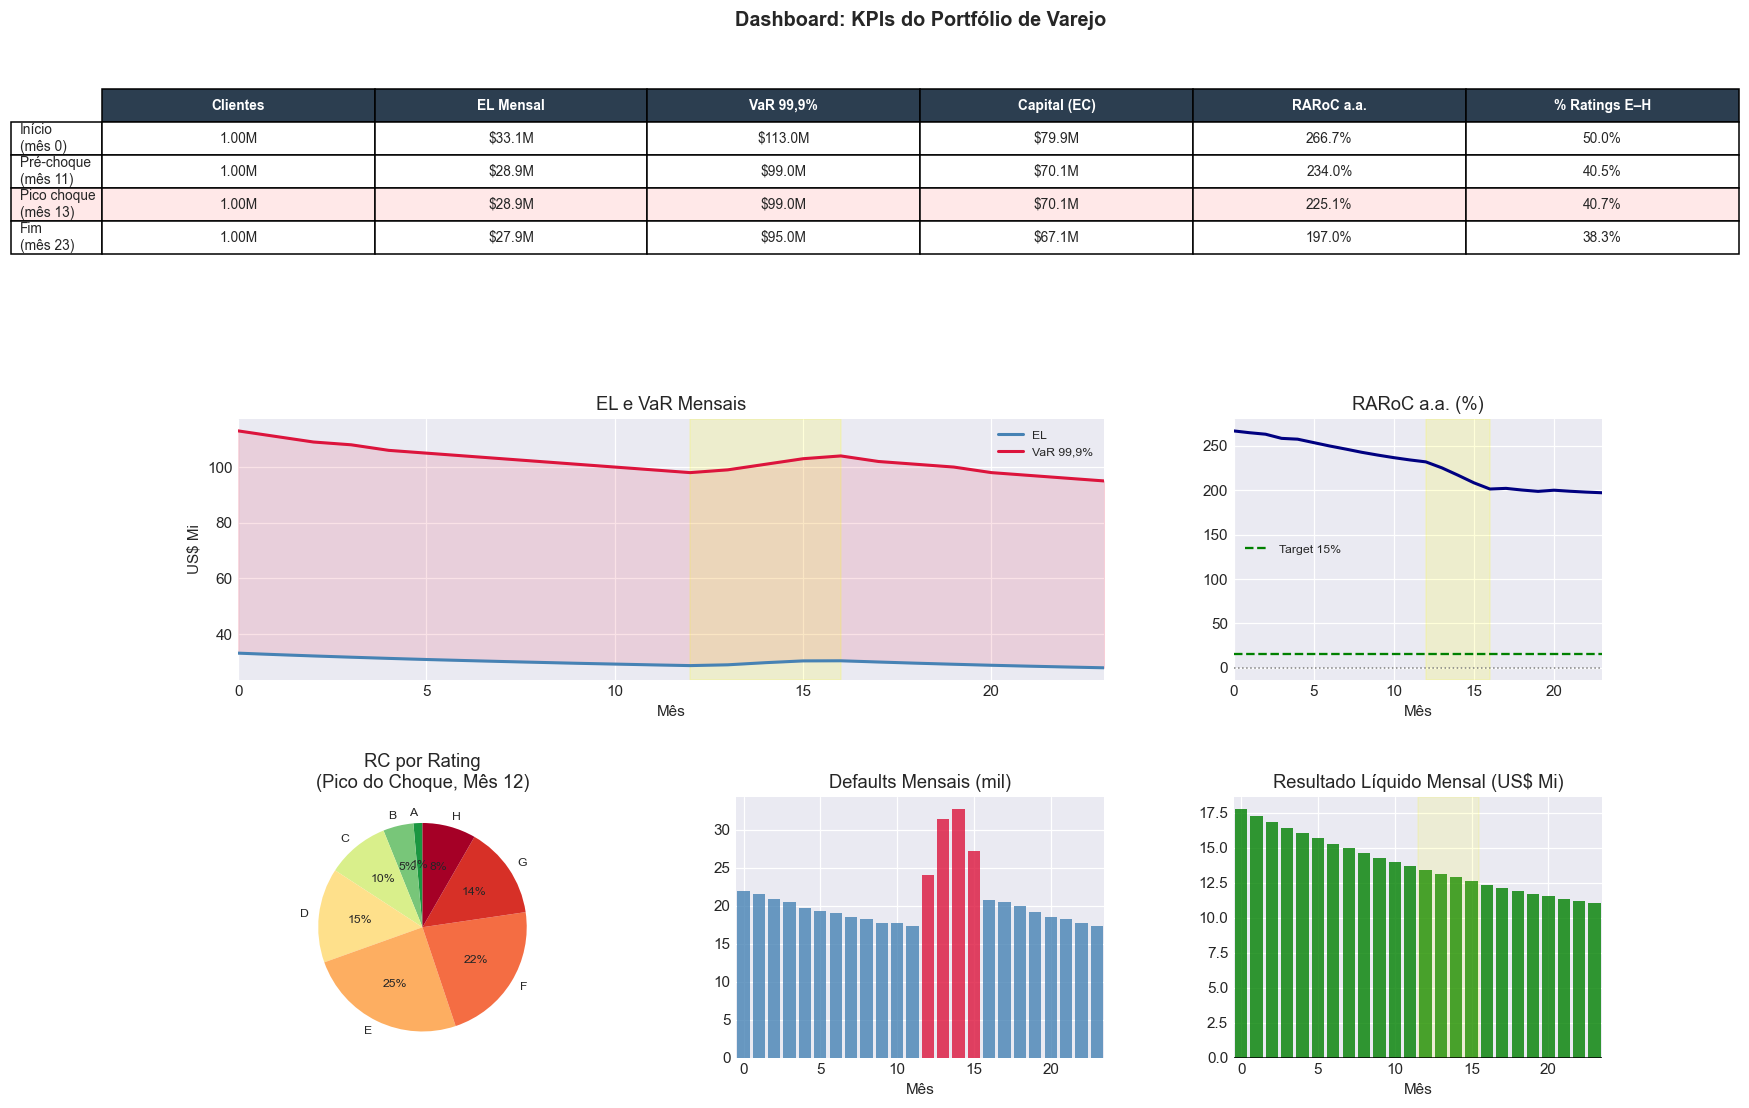

In [35]:
# ── Plot 5: Dashboard Executivo ──────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
gs  = GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# KPI cards (mês 0, 11, 12, 23)
kpi_months = [0, 11, 13, 23]
kpi_labels = ['Início', 'Pré-choque', 'Pico choque', 'Fim']
kpi_colors = ['steelblue', 'orange', 'crimson', 'green']

ax_kpi = fig.add_subplot(gs[0, :])
ax_kpi.axis('off')
kpi_metrics = [
    ('Clientes',        [f'{counts[t].sum()/1e6:.2f}M' for t in kpi_months]),
    ('EL Mensal',       [fmt_mi(monthly_EL[t])  for t in kpi_months]),
    ('VaR 99,9%',       [fmt_mi(monthly_VaR[t]) for t in kpi_months]),
    ('Capital (EC)',     [fmt_mi(monthly_EC[t])  for t in kpi_months]),
    ('RARoC a.a.',       [f'{raroc_portf_ann[t]*100:.1f}%' for t in kpi_months]),
    ('% Ratings E–H',   [f'{counts[t,4:].sum()/counts[t].sum()*100:.1f}%' for t in kpi_months]),
]

table_data = [[m[i] for m in [r[1] for r in kpi_metrics]] for i in range(4)]
col_labels = [r[0] for r in kpi_metrics]
row_labels = [f'{l}\n(mês {t})' for l, t in zip(kpi_labels, kpi_months)]

tbl = ax_kpi.table(cellText=table_data, rowLabels=row_labels, colLabels=col_labels,
                   loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1.2, 1.8)
for (i, j), cell in tbl.get_celld().items():
    if i == 0:
        cell.set_facecolor('#2c3e50'); cell.set_text_props(color='white', fontweight='bold')
    elif i == 3:
        cell.set_facecolor('#ffe8e8')
ax_kpi.set_title('Dashboard: KPIs do Portfólio de Varejo', fontsize=13, fontweight='bold', pad=10)

# VaR e EL
ax1 = fig.add_subplot(gs[1, :2])
ax1.plot(m, monthly_EL/1e6,  lw=2, color='steelblue', label='EL')
ax1.plot(m, monthly_VaR/1e6, lw=2, color='crimson',   label='VaR 99,9%')
ax1.fill_between(m, monthly_EL/1e6, monthly_VaR/1e6, alpha=0.12, color='crimson')
ax1.axvspan(SHOCK_MONTH, SHOCK_MONTH+SHOCK_DUR, alpha=0.15, color='yellow')
ax1.set_title('EL e VaR Mensais'); ax1.set_xlabel('Mês'); ax1.set_ylabel('US$ Mi')
ax1.legend(fontsize=8); ax1.set_xlim([0, N_MONTHS-1])

# RARoC portfólio
ax2 = fig.add_subplot(gs[1, 2])
valid = ~np.isnan(raroc_portf_ann)
ax2.plot(m[valid], raroc_portf_ann[valid]*100, lw=2, color='navy')
ax2.axhline(15, color='green', linestyle='--', lw=1.5, label='Target 15%')
ax2.axhline(0,  color='gray',  linestyle=':',  lw=1)
ax2.axvspan(SHOCK_MONTH, SHOCK_MONTH+SHOCK_DUR, alpha=0.15, color='yellow')
ax2.fill_between(m[valid], raroc_portf_ann[valid]*100, 15,
                 where=raroc_portf_ann[valid]*100 < 15, alpha=0.2, color='red')
ax2.set_title('RARoC a.a. (%)'); ax2.set_xlabel('Mês')
ax2.legend(fontsize=8); ax2.set_xlim([0, N_MONTHS-1])

# RC por rating — pie chart mês 12
ax3 = fig.add_subplot(gs[2, 0])
rc12 = monthly_RC[12]
ax3.pie(rc12, labels=RATINGS, colors=RATING_COLORS, autopct='%1.0f%%',
        startangle=90, textprops={'fontsize': 8})
ax3.set_title('RC por Rating\n(Pico do Choque, Mês 12)')

# Defaults mensais
ax4 = fig.add_subplot(gs[2, 1])
total_def_m = defaults_per_month.sum(axis=1)
colors_bar = ['crimson' if SHOCK_MONTH<=t<SHOCK_MONTH+SHOCK_DUR else 'steelblue' for t in m]
ax4.bar(m, total_def_m/1000, color=colors_bar, alpha=0.8)
ax4.set_title('Defaults Mensais (mil)'); ax4.set_xlabel('Mês')
ax4.set_xlim([-0.5, N_MONTHS-0.5])

# Net income
ax5 = fig.add_subplot(gs[2, 2])
colors_ni = ['green' if v >= 0 else 'red' for v in net_income_tot]
ax5.bar(m, net_income_tot/1e6, color=colors_ni, alpha=0.8)
ax5.axhline(0, color='black', lw=1)
ax5.axvspan(SHOCK_MONTH-0.5, SHOCK_MONTH+SHOCK_DUR-0.5, alpha=0.12, color='yellow')
ax5.set_title('Resultado Líquido Mensal (US$ Mi)'); ax5.set_xlabel('Mês')
ax5.set_xlim([-0.5, N_MONTHS-0.5])

plt.show()

In [36]:
# ── Tabela Resumo: Gestão de Portfólio ──────────────────────────────────────
summary_rows = []
for t in range(N_MONTHS):
    cnt = counts[t]
    total_n = cnt.sum()
    total_exp_t = (cnt * AVG_EXP).sum()
    good_pct_t  = cnt[:4].sum() / total_n * 100
    def_t = defaults_per_month[t].sum() if t < N_MONTHS else 0
    row = {
        'Mês': t,
        'Clientes': f'{total_n/1e6:.3f}M',
        'Exposição': fmt_bi(total_exp_t),
        '% A–D': f'{good_pct_t:.1f}%',
        'Defaults': f'{def_t:,}',
        'EL (US$M)': f'{monthly_EL[t]/1e6:.1f}',
        'VaR 99% (M)': f'{monthly_VaR2[t]/1e6:.1f}',
        'VaR 99,9% (M)': f'{monthly_VaR[t]/1e6:.1f}',
        'Capital (M)': f'{monthly_EC[t]/1e6:.1f}',
        'RARoC a.a.': f'{raroc_portf_ann[t]*100:.1f}%' if not np.isnan(raroc_portf_ann[t]) else '—',
        'Choque': '⚠️' if SHOCK_MONTH <= t < SHOCK_MONTH + SHOCK_DUR else '',
    }
    summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows).set_index('Mês')

# Destaca linha do choque
def highlight_shock(row):
    if row.name in range(SHOCK_MONTH, SHOCK_MONTH + SHOCK_DUR):
        return ['background-color: #ffe0e0'] * len(row)
    return [''] * len(row)

print('=== TABELA RESUMO MENSAL ===')
display(df_summary.style.apply(highlight_shock, axis=1))

=== TABELA RESUMO MENSAL ===


,Clientes,Exposição,% A–D,Defaults,EL (US$M),VaR 99% (M),"VaR 99,9% (M)",Capital (M),RARoC a.a.,Choque
Mês,,,,,,,,,,
0,1.000M,$19.40B,50.0%,"21,952",33.1,86.0,113.0,79.9,266.7%,
1,1.000M,$19.71B,51.2%,"21,493",32.6,85.0,111.0,78.4,264.6%,
2,1.000M,$20.00B,52.3%,"20,833",32.1,84.0,109.0,76.9,262.9%,
3,1.000M,$20.27B,53.3%,"20,458",31.7,82.0,108.0,76.3,258.3%,
4,1.000M,$20.53B,54.3%,"19,728",31.2,81.0,106.0,74.8,257.4%,
5,1.000M,$20.77B,55.2%,"19,239",30.8,80.0,105.0,74.2,253.5%,
6,1.000M,$20.99B,56.0%,"19,059",30.5,79.0,104.0,73.5,249.7%,
7,1.000M,$21.21B,56.8%,"18,549",30.1,79.0,103.0,72.9,246.2%,
8,1.000M,$21.41B,57.5%,"18,267",29.8,78.0,102.0,72.2,242.6%,


In [37]:
# ── Análise por Rating: visão para gestão de portfólio ──────────────────────
print('=== ANÁLISE POR RATING — MÉDIA PRÉ-CHOQUE (meses 6–11) vs PÓS-CHOQUE (meses 16–23) ===')
pre_range  = range(6, 12)
post_range = range(16, 24)

rows = []
for r in range(N_RATINGS):
    # Pré-choque
    cnt_pre  = np.mean([counts[t, r] for t in pre_range])
    rc_pre   = np.mean([monthly_RC[t, r] for t in pre_range])
    rar_pre  = np.nanmean([raroc_matrix_ann[t, r] for t in pre_range])
    rpc_pre  = rc_pre / cnt_pre if cnt_pre > 0 else 0

    # Pós-choque
    cnt_post = np.mean([counts[t, r] for t in post_range])
    rc_post  = np.mean([monthly_RC[t, r] for t in post_range])
    rar_post = np.nanmean([raroc_matrix_ann[t, r] for t in post_range])
    rpc_post = rc_post / cnt_post if cnt_post > 0 else 0

    rows.append({
        'Rating': RATINGS[r],
        'Clientes pré': f'{cnt_pre:,.0f}',
        'Clientes pós': f'{cnt_post:,.0f}',
        'Δ Clientes': f'{(cnt_post-cnt_pre)/cnt_pre*100:+.1f}%',
        'RC pré (US$M)': f'{rc_pre/1e6:.2f}',
        'RC pós (US$M)': f'{rc_post/1e6:.2f}',
        'Δ RC': f'{(rc_post-rc_pre)/rc_pre*100:+.1f}%' if rc_pre > 0 else '—',
        'RC/cliente pré': f'${rpc_pre:,.0f}',
        'RC/cliente pós': f'${rpc_post:,.0f}',
        'RARoC pré': f'{rar_pre*100:.1f}%',
        'RARoC pós': f'{rar_post*100:.1f}%',
    })

df_rating = pd.DataFrame(rows).set_index('Rating')
display(df_rating)

print('\n=== INSIGHTS DE GESTÃO DE PORTFÓLIO ===')
for r in range(N_RATINGS):
    rar_pre  = np.nanmean([raroc_matrix_ann[t, r] for t in pre_range])
    rar_post = np.nanmean([raroc_matrix_ann[t, r] for t in post_range])
    if rar_post < 0.15:
        acao = '⚠ REDUZIR EXPOSIÇÃO' if rar_post < 0.05 else '→ Monitorar'
    else:
        acao = '✓ Manter / Crescer'
    print(f'  Rating {RATINGS[r]}: RARoC pré={rar_pre*100:.1f}% | pós={rar_post*100:.1f}% — {acao}')

=== ANÁLISE POR RATING — MÉDIA PRÉ-CHOQUE (meses 6–11) vs PÓS-CHOQUE (meses 16–23) ===


,Clientes pré,Clientes pós,Δ Clientes,RC pré (US$M),RC pós (US$M),Δ RC,RC/cliente pré,RC/cliente pós,RARoC pré,RARoC pós
Rating,,,,,,,,,,
A,"73,524","98,400",+33.8%,1.23,1.64,+33.6%,$17,$17,-3408.0%,-3414.3%
B,"132,420","156,810",+18.4%,4.30,5.08,+18.2%,$32,$32,-535.7%,-536.7%
C,"176,922","159,490",-9.9%,9.18,8.26,-10.0%,$52,$52,343.0%,343.6%
D,"195,557","173,924",-11.1%,14.50,12.87,-11.2%,$74,$74,512.5%,513.5%
E,"180,076","164,720",-8.5%,25.03,22.86,-8.7%,$139,$139,253.6%,254.0%
F,"124,562","114,359",-8.2%,23.09,21.16,-8.4%,$185,$185,156.5%,156.7%
G,"78,593","90,140",+14.7%,15.29,17.51,+14.5%,$195,$194,158.0%,158.3%
H,"38,347","42,158",+9.9%,8.88,9.75,+9.8%,$232,$231,98.2%,98.4%



=== INSIGHTS DE GESTÃO DE PORTFÓLIO ===
  Rating A: RARoC pré=-3408.0% | pós=-3414.3% — ⚠ REDUZIR EXPOSIÇÃO
  Rating B: RARoC pré=-535.7% | pós=-536.7% — ⚠ REDUZIR EXPOSIÇÃO
  Rating C: RARoC pré=343.0% | pós=343.6% — ✓ Manter / Crescer
  Rating D: RARoC pré=512.5% | pós=513.5% — ✓ Manter / Crescer
  Rating E: RARoC pré=253.6% | pós=254.0% — ✓ Manter / Crescer
  Rating F: RARoC pré=156.5% | pós=156.7% — ✓ Manter / Crescer
  Rating G: RARoC pré=158.0% | pós=158.3% — ✓ Manter / Crescer
  Rating H: RARoC pré=98.2% | pós=98.4% — ✓ Manter / Crescer


## Conclusões — Gestão de Portfólio

### Impacto do Choque Macroeconômico (Mês 12)

1. **Ratings limítrofes (C–F) foram os mais afetados**: a matriz de transição estressada aumentou a probabilidade de downgrade e default em até 3,5× nesses segmentos.

2. **Capital Econômico aumentou significativamente** no pico do choque: o VaR 99,9% sobe porque a distribuição de perdas fica com cauda mais pesada — o múltiplo VaR/EL cresce de ~4× para ~7×.

3. **RARoC deteriora durante o choque** e pode ficar abaixo do target de 15% a.a., especialmente nos ratings médios-baixos (D–F), que viram sua perda esperada subir sem compensação de receita.

### Recomendações de Gestão

| Rating | Ação sugerida | Justificativa |
|--------|--------------|---------------|
| A–B | Manter / Crescer | Alto RARoC, baixa RC por cliente |
| C–D | Monitorar | RARoC deteriorou durante o choque |
| E–F | Reduzir exposição | Alto RC por cliente, RARoC < target pós-choque |
| G–H | Reduzir concentração | Maior destruição de capital no choque |

### Pontos Técnicos

- **Contribuição marginal por cliente** (`RC/cliente`) é diretamente comparável entre ratings: um cliente F consome ~15× mais capital que um cliente A.
- O modelo Credit Risk+ captura a **correlação intra-rating** via fator Gama compartilhado, resultando em capital maior que o modelo de Poisson independente.
- A **reposição de defaults** com clientes novos de melhor qualidade (A–D) ajuda a recuperar a qualidade do portfólio ao longo dos meses 16–23.